# Tutorial 7: Aligning spatial transcriptomics, spatial epigenomics data and H&E image of mouse embryonic brain data from MISAR-seq

## Data Preparation

Please download the required data files from the provided link:
[Download here](https://pan.baidu.com/s/17K1cmxOPmhSvV6dG6gnafw?pwd=sjbx)

- `E11_0-S1-HE.jpg`
- `E11.0-S1-RNA.h5ad`
- `E11.0-S2-genescore.h5ad`

After downloading, place both files into the `datasets` folder located in the same directory as this notebook.

The folder structure should be organized as follows:

```
project_root/
│
├── datasets/
│   └── MISAR2/
│       ├── E11_0-S1-HE.jpg
│       ├── E11.0-S1-RNA.h5ad
│       └── E11.0-S2-genescore.h5ad
│
├── Tutorial7_Aligning_spatial_transcriptomics_spatial_epigenomics_data_and_H&E_image_of_mouse_embryonic_brain_data_from_MISAR-seq.ipynb
│
└── SpaMOMA/
```

## import packages

In [1]:
import scanpy as sc
from SpaMOMA.SpaMOMA import SpaMOMA

## Specify Slice Metadata

In [2]:
save_directory = "./SpaMOMA_output/MISAR2/"  
spamoma = SpaMOMA(save_dir=save_directory)
spamoma.add_slice(
    sample_id="S1-HE", 
    raw_data_path="./datasets/MISAR2/E11_0-S1-HE.jpg",  
    feature="img"  
)
spamoma.add_slice(
    sample_id="S1-RNA", 
    raw_data_path="./datasets/MISAR2/E11.0-S1-RNA.h5ad", 
    feature="rna"  
)
spamoma.add_slice(
    sample_id="S2-ATAC",  
    raw_data_path="./datasets/MISAR2/E11.0-S2-genescore.h5ad",  
    feature="gene_activity_score"  
)
spamoma.set_reference('S1-HE')
print(f"aligning {[sid for sid in spamoma.input_slice_dict.keys() if sid != spamoma.reference_sample_id]} to {spamoma.reference_sample_id}")

aligning ['S1-RNA', 'S2-ATAC'] to S1-HE


## Data Preprocessing

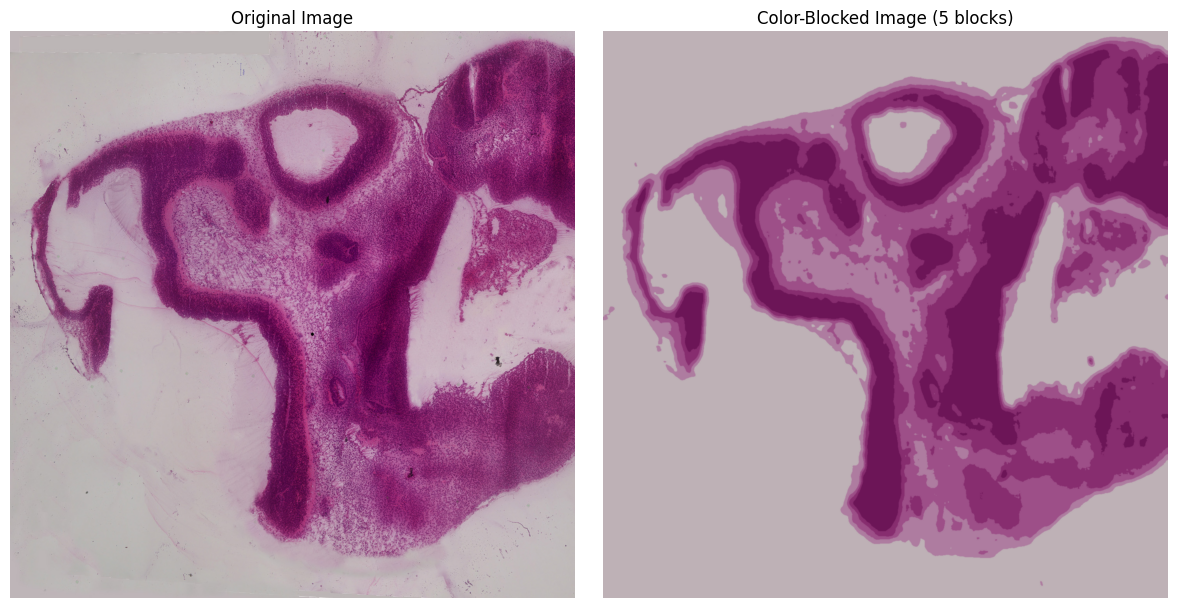

preprocessing rna features...


------Calculating spatial graph...


The graph contains 8841 edges, 1263 cells.
7.0000 neighbors per cell on average.
Size of Input:  (1263, 3000)


2026-02-19 14:28:18.909990: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-02-19 14:28:18.922390: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled



100%|██████████| 500/500 [00:51<00:00,  9.62it/s]

preprocessing gene_activity_score features...


------Calculating spatial graph...


The graph contains 9471 edges, 1353 cells.
7.0000 neighbors per cell on average.
Size of Input:  (1353, 3000)


2026-02-19 14:29:17.983758: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...



100%|██████████| 500/500 [00:27<00:00, 18.42it/s]

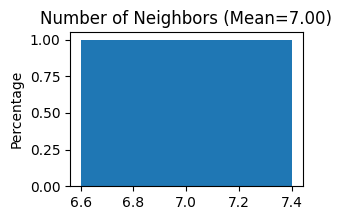

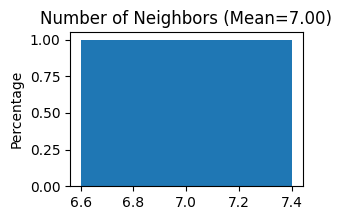

In [3]:
spamoma.preprocess_input_slices({
    'S1-HE':{
        'downsample':True
    }
})

## Generate Spatial Pattern Images

Color-quantized image saved to: ./SpaMOMA_output/MISAR2//S1-HE/RGB.png
generating spatial pattern image... gaussian_sigma:1.0, interpolation_method:linear, max_distance_ratio"0.9


saving image...


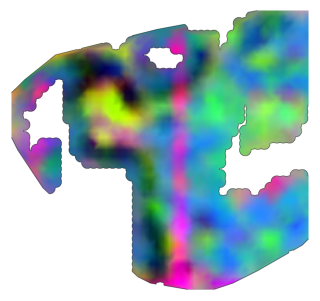

Img for S1-RNA is saved to ./SpaMOMA_output/MISAR2/S1-RNA/RGB.png
generating spatial pattern image... gaussian_sigma:1.0, interpolation_method:linear, max_distance_ratio"1.2


saving image...


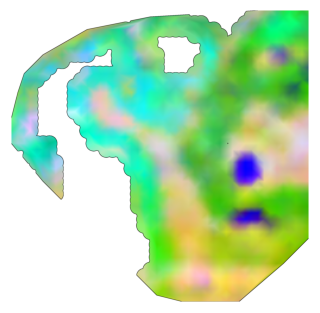

Img for S2-ATAC is saved to ./SpaMOMA_output/MISAR2/S2-ATAC/RGB.png


In [4]:
spamoma.generate_imgs({
    'S1-RNA':{
        'max_distance_ratio':0.9
    },
    'S2-ATAC':{
        'max_distance_ratio':1.2
    }
})

## Model Training

In [5]:
spamoma.train(parallel_mode=True,coarse_gpu=3,fine_gpu=1)

start coarse adaptation...
start fine adaptation...


fine adaptation done!
coarse adaptation done!


## Slice Alignment

In [6]:
spamoma.align_slices()

S1-HE image saved to: ./SpaMOMA_output/MISAR2//alignment_output/S1-HE.png
****************** aligning S1-RNA to S1-HE ..... ******************
start coarse alignment...
match params: {'model_key': 'roma', 'match_threshold': 0.999, 'extract_max_keypoints': 4096, 'force_resize': True, 'image_height': 560, 'image_width': 560, 'choice_geometry_type': 'Homography'}
Loading Roma model: ./SpaMOMA_output/MISAR2//coarse_model/adapted_model_epoch_1000.pth


current Roma instance ID: 128605150954832
preprocessing is already resized
Force resize to 560x560


coarse alignment done!
start fine alignment...
Loading Roma model: ./SpaMOMA_output/MISAR2//fine_model/adapted_model_epoch_300.pth


current Roma instance ID: 128601452554752
preprocessing is already resized
Force resize to 560x560


aligned S1-RNA adata is saved to: ./SpaMOMA_output/MISAR2//alignment_output/S1-RNA.h5ad
fine alignment done!


****************** aligning S2-ATAC to S1-HE ..... ******************
start coarse alignment...
match params: {'model_key': 'roma', 'match_threshold': 0.999, 'extract_max_keypoints': 4096, 'force_resize': True, 'image_height': 560, 'image_width': 560, 'choice_geometry_type': 'Homography'}
Loading Roma model: ./SpaMOMA_output/MISAR2//coarse_model/adapted_model_epoch_1000.pth


current Roma instance ID: 128602797373376
preprocessing is already resized
Force resize to 560x560


coarse alignment done!
start fine alignment...
Loading Roma model: ./SpaMOMA_output/MISAR2//fine_model/adapted_model_epoch_300.pth


current Roma instance ID: 128600096111632
preprocessing is already resized
Force resize to 560x560


aligned S2-ATAC adata is saved to: ./SpaMOMA_output/MISAR2//alignment_output/S2-ATAC.h5ad
fine alignment done!


## Visualize Alignment Results

Overlaying aligned slice for sample: S1-RNA
Overlaying aligned slice for sample: S2-ATAC


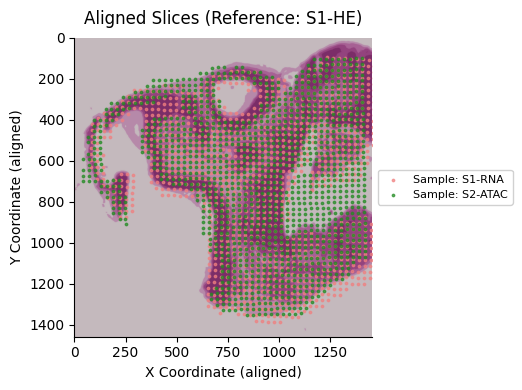

In [ ]:
spamoma.visualize_aligned_slices(point_size=3,figsize=(5, 4))

## Enhancing low resolution spots to pixel-level resolution based on aligned coordinates

In [8]:
low_res_adata=spamoma.read_aligned_data('S1-RNA')

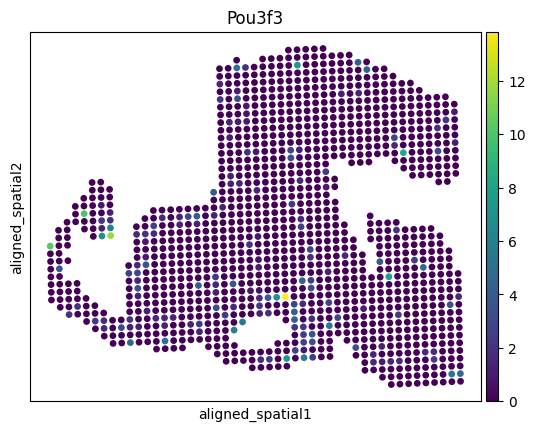

In [ ]:
sc.pl.embedding(low_res_adata,color='Pou3f3',basis='aligned_spatial')

In [ ]:
enhanced_adata=spamoma.SpaMOMA_enhance_resolution(adata=low_res_adata,img_path='./SpaMOMA_output/MISAR2/S1-HE/RGB.png')

Calculating MAGIC...
  Running MAGIC on 1263 cells and 31433 genes.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 12.75 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.20 seconds.
    Calculating affinities...
    Calculated affinities in 0.20 seconds.
  Calculated graph and diffusion operator in 13.16 seconds.
  Running MAGIC with `solver='exact'` on 31433-dimensional data may take a long time. Consider denoising specific genes with `genes=<list-like>` or using `solver='approximate'`.
  Calculating imputation...
  Calculated imputation in 0.17 seconds.
Calculated MAGIC in 13.37 seconds.
Number of valid sudo spots in tissue region: 11370
Number of valid known spots in tissue region: 1111
Total number of sudo points:  11370
Calculating spot 0
Calculating spot 1000
Calculating spot 2000
Calculating spot 3000
Calculating spot 4000
Calculating spot 5000
Calculating spot 6000
Calculating spot 7000
Calculating spot 8000
Calcu

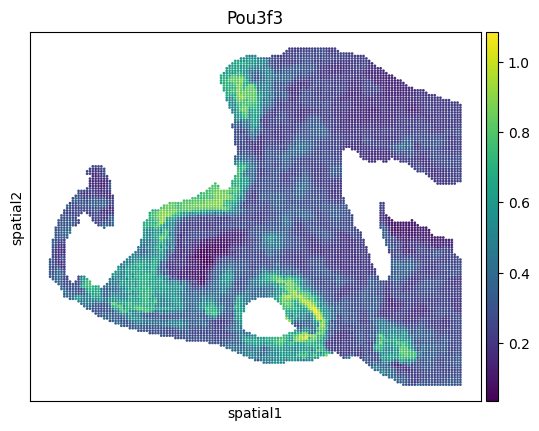

In [ ]:
sc.pl.embedding(enhanced_adata,color='Pou3f3',s=15,basis='spatial')